## Genomics

Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable. 

2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes. 

3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values. 

5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

7. Why do regularization methods lend themselves to scenarios like precision health? 

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

In [28]:
import pandas as pd
df = pd.read_csv('golub.csv', encoding = 'latin1')

(df.head())

,Samples,BM.PB,Gender,Source,tissue.mf,cancer,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
0,39,BM,F,DFCI,BM:f,allB,-1363.276427,-1058.585495,-541.469194,74.349803,...,-35.081447,1565.618803,-485.680714,-170.261227,-919.114293,1675.050053,389.769289,-526.449219,-268.963924,-779.643092
1,40,BM,F,DFCI,BM:f,allB,-796.285053,-1167.103365,7.538493,83.544731,...,-404.737767,622.498054,-1275.354673,214.828233,-750.220666,-441.589276,9.841713,-671.911209,-671.911209,-644.272577
2,42,BM,F,DFCI,BM:f,allB,-679.139168,-1069.832308,-690.301829,-112.075981,...,193.780934,162.525483,-692.534361,517.498108,-674.674103,1265.396405,-65.192805,-714.859684,3672.066149,-822.021231
3,47,BM,M,DFCI,BM:m,allB,-1164.400197,-1109.939891,-990.127218,-238.574994,...,-256.002292,-31.625831,-621.975549,-458.594630,-630.689198,937.767618,-264.715941,-635.046022,475.944222,-794.070116
4,48,BM,F,DFCI,BM:f,allB,-1299.653758,-1401.998536,-1077.543813,-437.344560,...,-509.203660,383.591216,-905.517483,-36.675640,-1116.739685,316.087213,-210.879518,-953.423549,-291.448812,-1057.945876


In [29]:
# relabeling the target variable to be binary: 0 for ALL (acute lymphoblastic leukemia) and 1 for AML (acute myeloid leukemia)
df["target"] = df["cancer"].str.lower().map({
    "allb": 0,
    "allt": 0,
    "aml": 1
})

# keep only rows with valid labels
df = df[df["target"].isin([0, 1])].copy()

print(df["target"].value_counts())


target
0    47
1    25
Name: count, dtype: int64


In [30]:
drop_cols = ["Samples", "BM.PB", "Gender", "Source", "tissue.mf", "cancer", "target"]
X = df.drop(columns=drop_cols)
y = df["target"]

print(X.shape)

(72, 7129)


In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

linreg = LinearRegression()
linreg.fit(X, y)

y_pred = linreg.predict(X)

mse = mean_squared_error(y, y_pred)
print("Training MSE:", mse)

Training MSE: 1.4452178302681818e-30


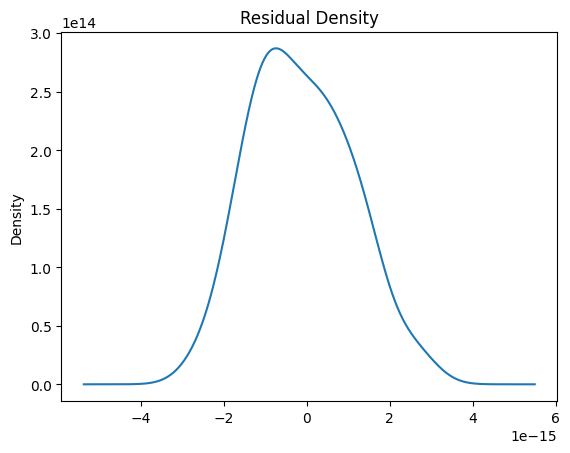

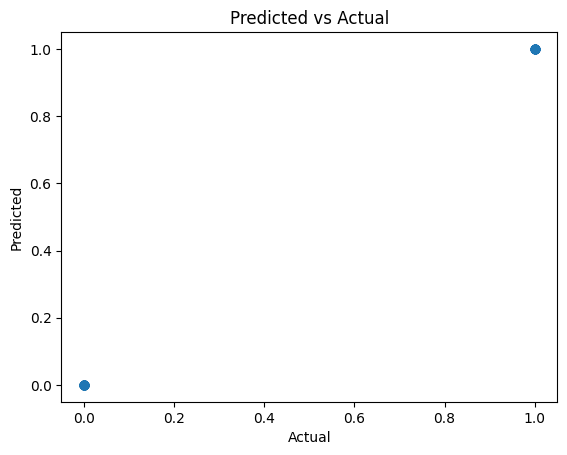

In [32]:
residuals = y - y_pred
pd.Series(residuals).plot(kind="density")
plt.title("Residual Density")
plt.show()

plt.scatter(y, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")
plt.show()

Answer to Question 2: A linear regression model was fit using all gene variables, resulting in a training mean squared error of approximately 1.45 x 10^-30, which is essentially zero. The residual density plot shows values tightly centered around zero, and the predicted vs. actual scatter plot shows near-perfect alignment. This indicates that the model fits the training data extremely well, but likely suffers from overfitting due to the large number of predictors relative to observations.

In [34]:
from sklearn.model_selection import KFold, cross_val_score
import numpy as np
import warnings

warnings.filterwarnings("ignore")

kf = KFold(n_splits=10, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    LinearRegression(),
    X,
    y,
    cv=kf,
    scoring="neg_mean_squared_error"
)

cv_mse = -cv_scores

print("CV MSEs:", cv_mse)
print("Mean CV MSE:", np.mean(cv_mse))

CV MSEs: [0.0459653  0.04231634 0.04823094 0.07943783 0.01576511 0.07586618
 0.06668908 0.03873804 0.01877966 0.02787012]
Mean CV MSE: 0.04596585937931273


Answer to question 3: Using 10-fold cross-validation, the mean squared error of the linear model was approximately 0.046. This is much larger than the near-zero training MSE, which shows that the model is overfitting the training data. From the bias-variance trade-off perspective, the model has low bias because it fits the training data extremely well, but high variance because its performance worsens on new data.

In [35]:
from sklearn.linear_model import LassoCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

lasso_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(cv=10, random_state=42, max_iter=100000))
])

lasso_pipe.fit(X, y)

best_alpha = lasso_pipe.named_steps["lasso"].alpha_
print("Best alpha:", best_alpha)

Best alpha: 0.0006701743064744873


In [36]:
lasso_model = lasso_pipe.named_steps["lasso"]
coef = pd.Series(lasso_model.coef_, index=X.columns)

selected_genes = coef[coef != 0]
print("Number of selected genes:", len(selected_genes))
print("Number of discarded genes:", X.shape[1] - len(selected_genes))
print(selected_genes)

Number of selected genes: 81
Number of discarded genes: 7048
AF000560_at           0.001586
AF002020_at          -0.001391
AF006087_at          -0.005813
D26579_at             0.002841
D29956_at            -0.000521
                        ...   
X85116_rna1_s_at      0.013100
HG4518-HT4921_r_at   -0.008009
L08010_at             0.013235
U84388_at            -0.010770
X06318_at            -0.000135
Length: 81, dtype: float64


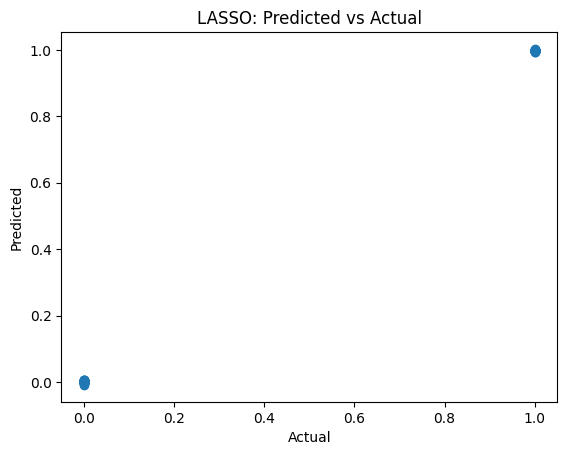

In [37]:
y_pred_lasso = lasso_pipe.predict(X)

plt.scatter(y, y_pred_lasso)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("LASSO: Predicted vs Actual")
plt.show()

Answer to Question 4: Using cross-validated LASSO, the optimal penalty parameter was α = 0.00067. The model selected 81 genes and discarded 7048 genes, producing a much sparser model compared to linear regression. By shrinking many coefficients to zero, LASSO reduces overfitting while keeping only the most predictive genes. The predicted versus actual scatter plot shows that the model still separates the two leukemia classes well, despite using far fewer predictors.